# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
from sklearn import linear_model
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('2_digital_marketing_campaign_dataset_use for main capstone data.csv')

MAGENTA    = "#E20074"
DARK_GRAY  = "#333333"
MID_GRAY   = "#888888"
LIGHT_GRAY = "#D9D9D9"

def style_ax(ax, title="", xlabel="", ylabel=""):
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(LIGHT_GRAY)
    ax.spines["bottom"].set_color(LIGHT_GRAY)
    ax.tick_params(colors=DARK_GRAY, labelsize=9)
    if title:  ax.set_title(title, fontsize=11, fontweight="bold", color=DARK_GRAY, loc="left", pad=8)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9, color=MID_GRAY)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9, color=MID_GRAY)

print("Dataset loaded!", df.shape)
print(df.columns.tolist())

Dataset loaded! (8000, 20)
['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']


# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

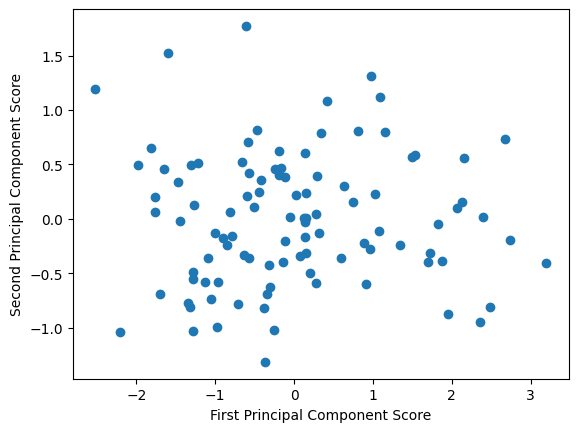

In [2]:
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

##

The three outliers in the upper left corner of the PCA scatter plot have a 
**low** first principal component score and a **high** second principal component score.

A low first principal component score tells us that all three series values 
for these outliers tend to be below average, since the first principal component 
captures the direction in which all three series move together.

The high second principal component score tells us something specific about 
series_3 given that it is unusually high relative to series_1 and series_2 for these 
outliers. In other words, even though the overall level of all three series is 
low, series_3 bucks that trend and pulls higher than expected.

It is very difficult to say anything about the relative values of series_1 and 
series_2 separately because they are strongly correlated with each other. Series_2 was constructed directly from series_1, so they move together almost perfectly. Knowing the first principal component score tells us they are both 
below average, but it cannot tell us which one is higher than the other.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
df = pd.read_csv('2_digital_marketing_campaign_dataset_use for main capstone data.csv')

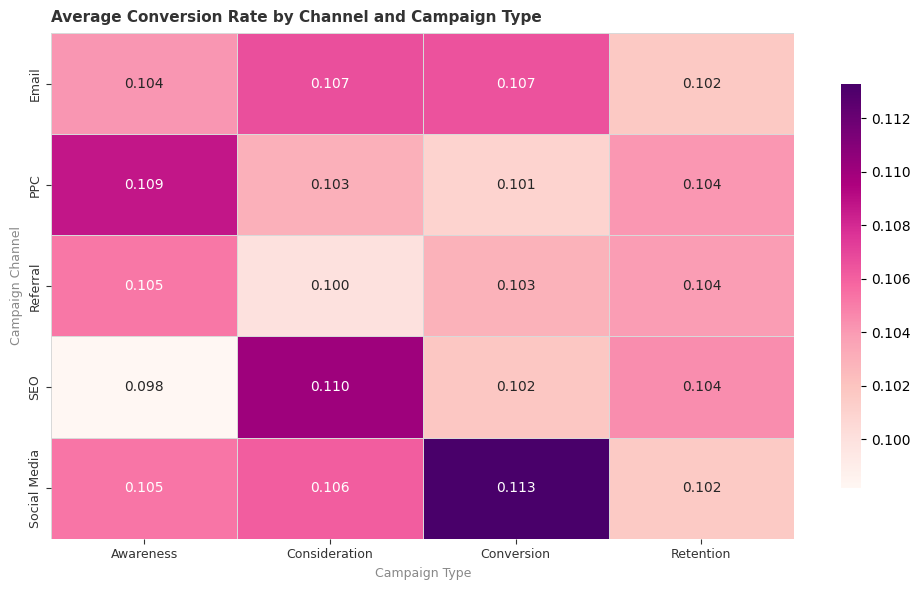

In [4]:
# HEATMAP 1: Average Conversion Rate by Channel and Campaign Type
pivot = df.pivot_table(
    index='CampaignChannel',
    columns='CampaignType',
    values='ConversionRate',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, 
            cmap='RdPu',
            annot=True, 
            fmt='.3f',
            linewidths=0.5,
            linecolor=LIGHT_GRAY,
            ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Average Conversion Rate by Channel and Campaign Type',
             fontsize=11, fontweight='bold', color=DARK_GRAY, loc='left', pad=8)
ax.set_xlabel('Campaign Type', fontsize=9, color=MID_GRAY)
ax.set_ylabel('Campaign Channel', fontsize=9, color=MID_GRAY)
ax.tick_params(colors=DARK_GRAY, labelsize=9)
plt.tight_layout()
plt.show()

## Heatmap 1 Analysis

The heatmap reveals that most channel and campaign type combinations produce similar average conversion rates, hovering between 0.100 and 0.107. However, two combinations stand out: Social Media paired with Conversion campaigns achieves the highest average conversion rate (0.113), while SEO paired with Awareness campaigns produces the lowest (0.098). This suggests that matching the right channel to the right campaign type — specifically social media for 
conversion-focused campaigns — may yield modest but meaningful performance gains.

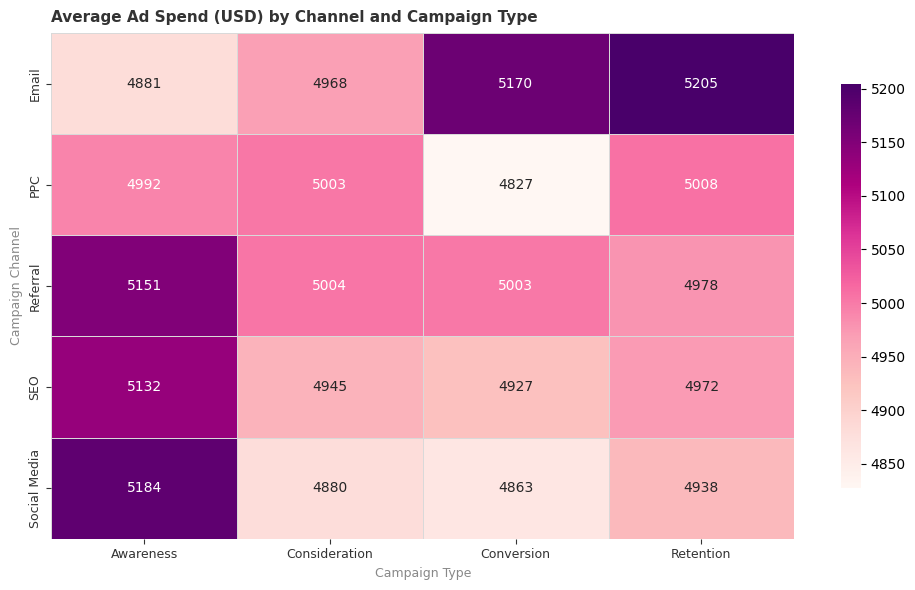

In [5]:
# HEATMAP 2 (Extra): Average Ad Spend by Channel and Campaign Type
pivot2 = df.pivot_table(
    index='CampaignChannel',
    columns='CampaignType',
    values='AdSpend',
    aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot2,
            cmap='RdPu',
            annot=True,
            fmt='.0f',
            linewidths=0.5,
            linecolor=LIGHT_GRAY,
            ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Average Ad Spend (USD) by Channel and Campaign Type',
             fontsize=11, fontweight='bold', color=DARK_GRAY, loc='left', pad=8)
ax.set_xlabel('Campaign Type', fontsize=9, color=MID_GRAY)
ax.set_ylabel('Campaign Channel', fontsize=9, color=MID_GRAY)
ax.tick_params(colors=DARK_GRAY, labelsize=9)
plt.tight_layout()
plt.show()

## Heatmap 2 Analysis (Extra)

Ad spend is relatively consistent across all channel and campaign type combinations, ranging from approximately $4,827 to $5,205 USD. Notably, the combinations with the highest ad spend do not align with those showing the highest conversion rates in the previous heatmap. For example, Email paired with Retention campaigns carries the highest average spend at $5,205, yet only achieves a conversion rate of 0.102. Meanwhile, Social Media paired with Conversion campaigns achieves the highest conversion rate in the dataset (0.113) at a comparatively modest spend of $4,863. This misalignment between spend and performance suggests potential inefficiencies in budget allocation. It also points to Social Media Conversion campaigns as the strongest return on investment combination in this dataset.

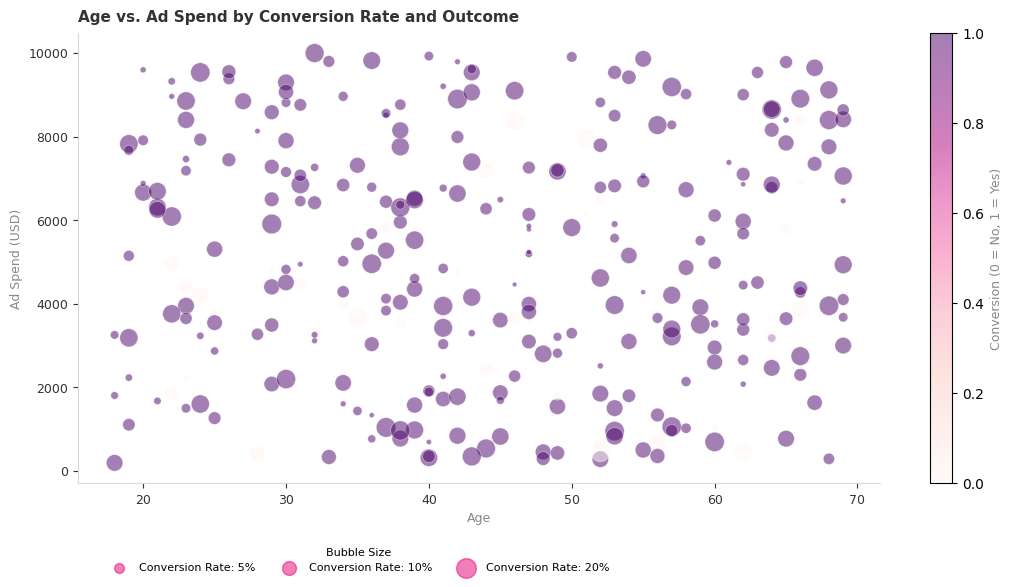

In [6]:
df_sample = df.sample(300, random_state=42)

fig, ax = plt.subplots(figsize=(11, 6))

bubble_sizes = df_sample['ConversionRate'] * 1000

scatter = ax.scatter(
    df_sample['Age'],
    df_sample['AdSpend'],
    s=bubble_sizes,
    c=df_sample['Conversion'],
    cmap='RdPu',
    alpha=0.5,
    edgecolors='white',
    linewidths=0.5
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Conversion (0 = No, 1 = Yes)', fontsize=9, color=MID_GRAY)

style_ax(ax,
         title='Age vs. Ad Spend by Conversion Rate and Outcome',
         xlabel='Age',
         ylabel='Ad Spend (USD)')

for rate in [0.05, 0.10, 0.20]:
    ax.scatter([], [], s=rate*1000, c='#E20074', alpha=0.5,
               label=f'Conversion Rate: {rate:.0%}')

ax.legend(title='Bubble Size', frameon=False, fontsize=8,
          title_fontsize=8, loc='lower center',
          bbox_to_anchor=(0.35, -0.22), ncol=3)

plt.tight_layout()
plt.show()

## Bubble Plot Analysis

The bubble plot examines three variables simultaneously: customer age, ad spend, and conversion rate. The bubble color indicates whether a conversion occurred. The overall pattern shows no strong relationship between age and ad spend. Bubble sizes are randomly distributed across all age groups and spend levels. This confirms the earlier finding from Milestone 3 that demographic variables like age have virtually no predictive relationship with conversion outcomes. High and low conversion rates appear equally across all ages and budget levels, suggesting that neither age nor ad spend alone drives conversion in this dataset.

In [7]:
# Select numeric behavioral variables for PCA
numeric_cols = ['AdSpend', 'ClickThroughRate', 'ConversionRate', 
                'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 
                'EmailOpens', 'EmailClicks', 'LoyaltyPoints']

df_pca = df[numeric_cols]
df_pca_scaled = df_pca - df_pca.mean()

# Run PCA
pca = decomposition.PCA(n_components=3)
pca.fit(df_pca_scaled)

print("=== VARIANCE EXPLAINED ===")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"Component {i+1}: {var:.2%}")

print("\n=== COMPONENT VECTORS ===")
for i, comp in enumerate(pca.components_):
    print(f"\nComponent {i+1}:")
    for col, val in zip(numeric_cols, comp):
        print(f"  {col}: {val:.3f}")

=== VARIANCE EXPLAINED ===
Component 1: 79.76%
Component 2: 20.24%
Component 3: 0.00%

=== COMPONENT VECTORS ===

Component 1:
  AdSpend: 1.000
  ClickThroughRate: -0.000
  ConversionRate: -0.000
  WebsiteVisits: 0.000
  PagesPerVisit: -0.000
  TimeOnSite: -0.000
  EmailOpens: 0.000
  EmailClicks: 0.000
  LoyaltyPoints: 0.001

Component 2:
  AdSpend: -0.001
  ClickThroughRate: -0.000
  ConversionRate: -0.000
  WebsiteVisits: 0.000
  PagesPerVisit: -0.000
  TimeOnSite: -0.000
  EmailOpens: -0.000
  EmailClicks: -0.000
  LoyaltyPoints: 1.000

Component 3:
  AdSpend: -0.000
  ClickThroughRate: -0.000
  ConversionRate: -0.000
  WebsiteVisits: 1.000
  PagesPerVisit: -0.002
  TimeOnSite: -0.007
  EmailOpens: 0.003
  EmailClicks: 0.001
  LoyaltyPoints: -0.000


Component 1 (79.76%) — almost entirely AdSpend (1.000). Everything else is basically zero. This means AdSpend has by far the largest spread in the data and dominates the first component.

Component 2 (20.24%) — captures everything else combined, but all the values are tiny (around 0.000-0.007).

Component 3 (0.00%) — essentially nothing left to explain.

This makes sense and matches what we found in Milestone 3. AdSpend ranges from $100 to $10,000 (a wide spread), while variables like ClickThroughRate only range from 0.01 to 0.30 (tiny spread). PCA grabs AdSpend first because it varies the most.

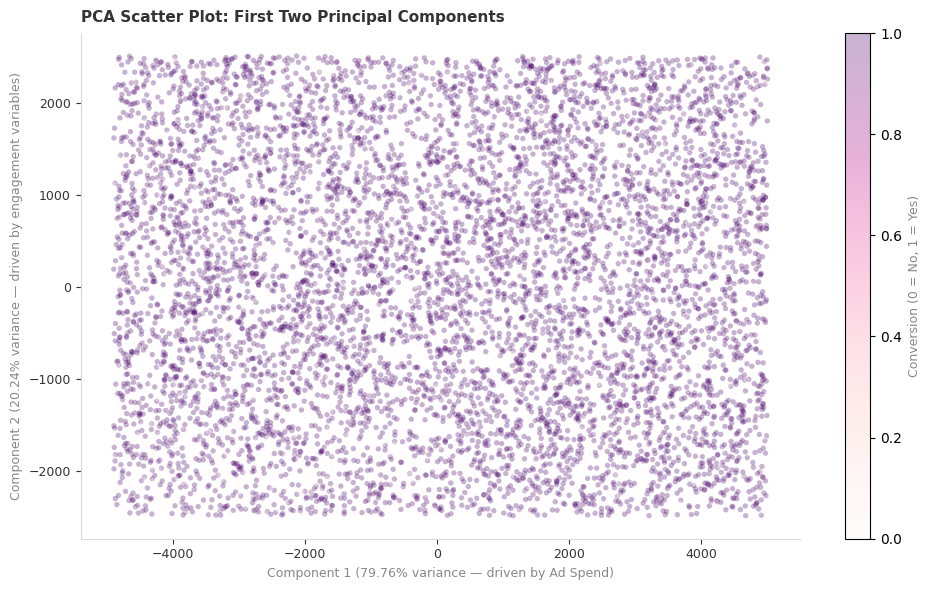

In [8]:
# PCA Scatter Plot - first two components
pc1_scores = df_pca_scaled.dot(pca.components_[0])
pc2_scores = df_pca_scaled.dot(pca.components_[1])

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(pc1_scores, pc2_scores,
                     c=df['Conversion'],
                     cmap='RdPu',
                     alpha=0.3,
                     s=15,
                     edgecolors='none')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Conversion (0 = No, 1 = Yes)', fontsize=9, color=MID_GRAY)

style_ax(ax,
         title='PCA Scatter Plot: First Two Principal Components',
         xlabel=f'Component 1 (79.76% variance — driven by Ad Spend)',
         ylabel=f'Component 2 (20.24% variance — driven by engagement variables)')

plt.tight_layout()
plt.show()

## PCA Analysis

The PCA of the nine numeric behavioral variables reveals that Component 1 captures 79.76% of the variance and is driven almost entirely by AdSpend, which has by far the largest range in the dataset ($100 to $10,000). Component 2 captures the remaining 20.24% and reflects the smaller engagement variables such as TimeOnSite, EmailOpens, and EmailClicks. Component 3 explains essentially no additional variance.

This result is consistent with findings from Milestone 3. AdSpend dominates the data's variation because its scale is much larger than the other variables. The PCA scatter plot shows no clear separation between converted and non-converted customers, further confirming that no single combination of these variables predicts conversion outcome.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

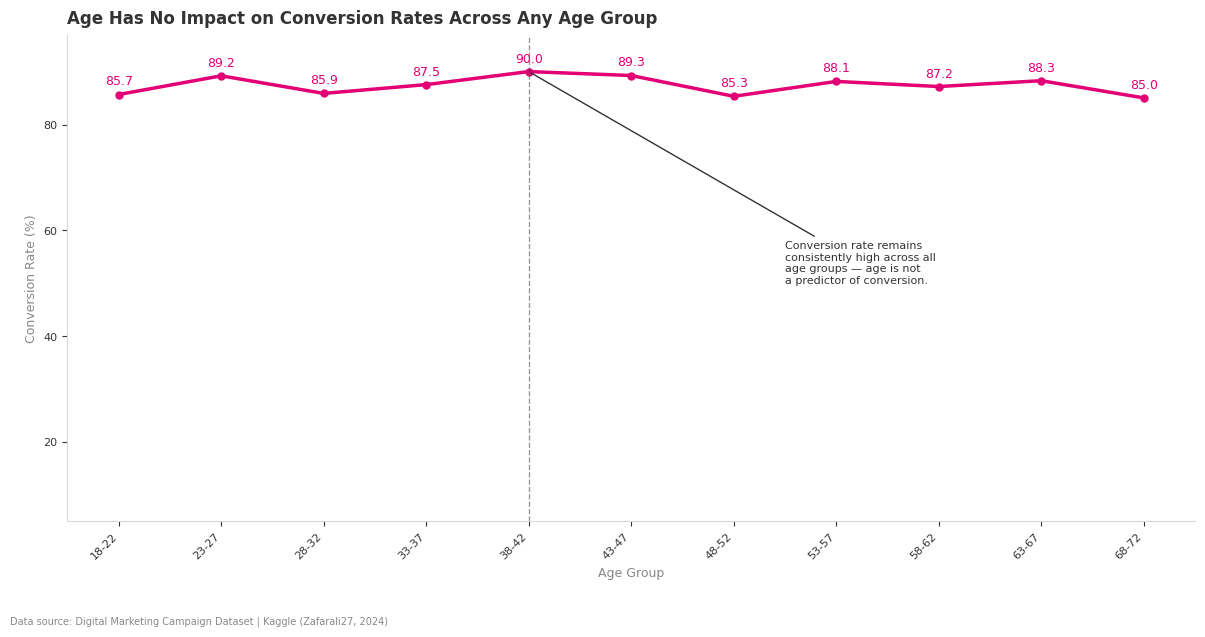

In [9]:
df['AgeGroup'] = pd.cut(df['Age'], bins=range(18, 75, 5), 
                         labels=[f'{i}-{i+4}' for i in range(18, 70, 5)])
age_binary = df.groupby('AgeGroup', observed=True)['Conversion'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(len(age_binary)), age_binary.values,
        color=MAGENTA, linewidth=2.5, marker='o', markersize=5)

for i, val in enumerate(age_binary.values):
    ax.text(i, val + 1.8, f'{val:.1f}', ha='center', fontsize=9, color=MAGENTA)

ax.axvline(x=4, color=DARK_GRAY, linewidth=1, linestyle='--', alpha=0.5)

ax.annotate('Conversion rate remains\nconsistently high across all\nage groups — age is not\na predictor of conversion.',
            xy=(4, age_binary.values[4]),
            xytext=(6.5, 50),
            fontsize=8,
            color=DARK_GRAY,
            arrowprops=dict(arrowstyle='-', color=DARK_GRAY, lw=1))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color(LIGHT_GRAY)
ax.spines['bottom'].set_color(LIGHT_GRAY)
ax.set_xticks(range(len(age_binary)))
ax.set_xticklabels(age_binary.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Conversion Rate (%)', fontsize=9, color=MID_GRAY)
ax.set_xlabel('Age Group', fontsize=9, color=MID_GRAY)
ax.tick_params(colors=DARK_GRAY, labelsize=8)
ax.set_ylim(5, 97)

ax.set_title('Age Has No Impact on Conversion Rates Across Any Age Group',
             fontsize=12, fontweight='bold', color=DARK_GRAY, loc='left', pad=8)

fig.text(0, -0.05, 'Data source: Digital Marketing Campaign Dataset | Kaggle (Zafarali27, 2024)',
         fontsize=7, color=MID_GRAY)

plt.tight_layout()
plt.show()